## Annual Climate Data for Death Valley, California

In [1]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot ### plotting
import hvplot.pandas ### make interactive plots
import pandas as pd ### work with tabular data in data frames

import matplotlib.pyplot as plt ### plotting tool
import seaborn as sns ### statistical plots

from sklearn.linear_model import LinearRegression ### fit an OLS linear regression

In [44]:
### Set weather station information 

### NCEI base url
ncei_base = 'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries'

### Station Data URL: https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00042319/detail

### Station Name
station_name = 'Death Valley National Park, CA'

### Station ID
station_id = 'USC00042319'
url_station = '&stations='+station_id

### Data Type
climate_data_type = 'TOBS' #,TMAX,TMIN
url_data_type = '&dataTypes='+climate_data_type

### Data Record Start Date
start_date = '1962-01-01' # observations start date: 1961-04-26
url_start = '&startDate='+start_date

### Data Record End Date
end_date = '2021-12-31' # last date with recorded TOBS
url_end = '&endDate='+end_date

### Data Units (standard (F) or metric (C))
data_units = 'metric'
url_units = '&units='+data_units

### Assemble full URL concatenating pieces assembled above

ncei_url = ncei_base + url_data_type + url_station + url_start + url_end+url_units

print(ncei_url)


https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00042319&startDate=1962-01-01&endDate=2021-12-31&units=metric


In [45]:
# Load climate data from NCEI
climate_df = pd.read_csv(ncei_url, 
    index_col = 'DATE', parse_dates = True, na_values = ['NaN']
    )



In [46]:
### Check to make sure data exists for selected dates and verify units

# beginning of data set
print(climate_df.head())

# end of data set 
print(climate_df.tail())

                STATION  TOBS
DATE                         
1962-01-01  USC00042319  12.8
1962-01-02  USC00042319  16.7
1962-01-03  USC00042319  15.6
1962-01-04  USC00042319  22.8
1962-01-05  USC00042319  17.2
                STATION  TOBS
DATE                         
2021-12-27  USC00042319   8.3
2021-12-28  USC00042319   7.2
2021-12-29  USC00042319   8.9
2021-12-30  USC00042319   9.4
2021-12-31  USC00042319  10.6


<Axes: ylabel='Frequency'>

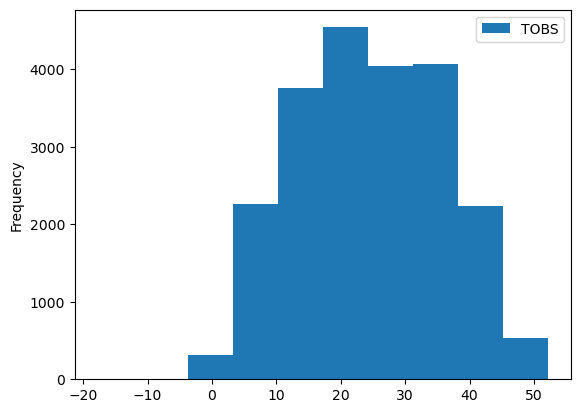

In [47]:
### Check distribution of missing temperature values (NaNs)
climate_df.plot.hist()

In [48]:
### Check data for null values
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21914 entries, 1962-01-01 to 2021-12-31
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  21914 non-null  object 
 1   TOBS     21766 non-null  float64
dtypes: float64(1), object(1)
memory usage: 513.6+ KB


In [49]:
### filter data frame to keep temperature observed (TOBS) to new data frame
temp_df = climate_df[['TOBS']]

### rename TOBS to temp with proper unit
if data_units == 'metric':
    temp_df = temp_df.rename(columns = {'TOBS':'temp_c'})
elif data_units == 'standard':
    temp_df = temp_df.rename(columns = {'TOBS':'temp_f'})
else:
    temp_df = temp_df.rename(columns = {'TOBS':'temp_unk'})
### check updated data frame
temp_df

,temp_c
DATE,
1962-01-01,12.8
1962-01-02,16.7
1962-01-03,15.6
1962-01-04,22.8
1962-01-05,17.2
...,...
2021-12-27,8.3
2021-12-28,7.2
2021-12-29,8.9


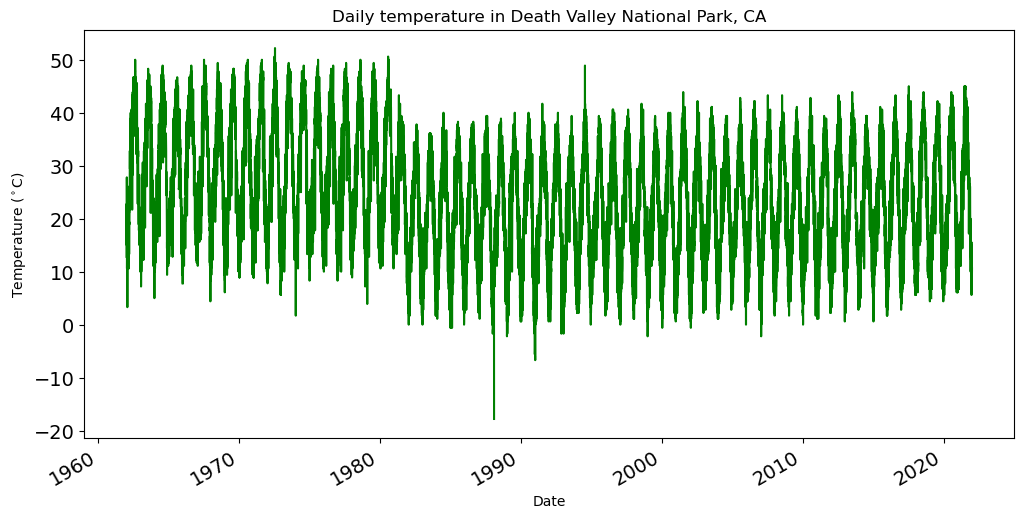

In [50]:
### plot with modifications
temp_modified = temp_df.plot(
    y = 'temp_c',
    title = 'Daily temperature in '+station_name,
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)', 
    figsize = (12,6),
    fontsize = 14,
    color = 'green',
    #kind = 'bar'
    )

temp_modified.legend().remove()

In [51]:
### find mean annual temp

ann_temp_df = (
    temp_df # data source
    .resample('YS') # resample frequency: annual/year start
    .mean() # aggregation method
)

ann_temp_df

,temp_c
DATE,
1962-01-01,30.929945
1963-01-01,30.100549
1964-01-01,30.120994
1965-01-01,29.466391
1966-01-01,30.798061
1967-01-01,30.046301
1968-01-01,30.045082
1969-01-01,29.961096
1970-01-01,29.893425


<Axes: title={'center': 'Mean annual temperature in Death Valley National Park, CA'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

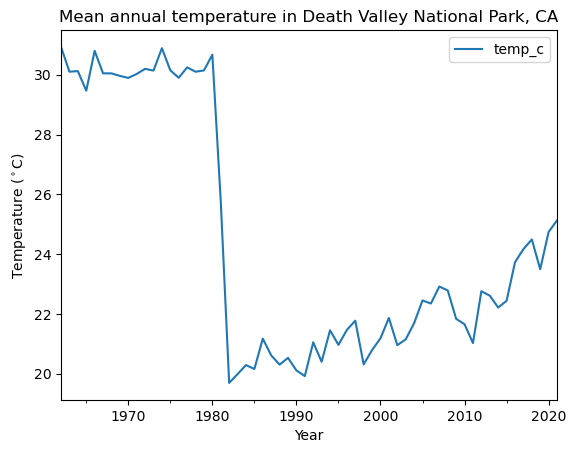

In [52]:
ann_temp_df.plot(
    y = 'temp_c',
    title = 'Mean annual temperature in '+station_name,
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [ ]:
hvplot.extension("bokeh")

### plot the annual data interactively

ann_temp_plot = ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean annual temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

ann_temp_plot

In [ ]:
hv.save(ann_temp_plot, 'annual_temp_plot_boulder.html')

In [ ]:
### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### remove na data from data frame
ann_temp_df = ann_temp_df.dropna()

### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### reduce data set to only celcius and date 
ann_temp_c_df = ann_temp_df[['temp_c']]

### filter data to avoid data gap and use only 1941-2023
clean_ann_temp_c_df = ann_temp_c_df.loc['1941':'2023']

clean_ann_temp_c_df.head()

### create two subset groups of years that show different slopes
### 1941-1980
early_ann_temp_df = clean_ann_temp_c_df.loc['1941':'1980']
### 1980-2023
late_ann_temp_df = clean_ann_temp_c_df.loc['1980':'2023']


In [ ]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x = clean_ann_temp_c_df.index.year.values.reshape(-1, 1)

### define dependent variable
y = clean_ann_temp_c_df.temp_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(x, y)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

In [ ]:
### plot data
ax = sns.regplot(
    x = clean_ann_temp_c_df.index.year, 
    y = clean_ann_temp_c_df.temp_c,

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in Boulder, CO (1941-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_boulder.jpeg')

### plot it
plt.show()